In [1]:
# Create analyze_images.ipynb
import cv2
import numpy as np
from matplotlib import pyplot as plt

ModuleNotFoundError: No module named 'cv2'

In [5]:


def analyze_color_distribution(image, title):
    """Analyze color channels of an image"""
    
    # Convert to RGB
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Split channels
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    
    # Plot histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title(f"{title} - Original")
    axes[0, 0].axis('off')
    
    # Red channel
    axes[0, 1].hist(r.ravel(), bins=256, color='red', alpha=0.7)
    axes[0, 1].set_title('Red Channel Distribution')
    axes[0, 1].set_xlim([0, 255])
    
    # Green channel
    axes[1, 0].hist(g.ravel(), bins=256, color='green', alpha=0.7)
    axes[1, 0].set_title('Green Channel Distribution')
    axes[1, 0].set_xlim([0, 255])
    
    # Blue channel
    axes[1, 1].hist(b.ravel(), bins=256, color='blue', alpha=0.7)
    axes[1, 1].set_title('Blue Channel Distribution')
    axes[1, 1].set_xlim([0, 255])
    
    plt.tight_layout()
    plt.savefig(f"results/color_analysis_{title}.png")
    plt.show()
    
    # Calculate statistics
    stats = {
        'mean_red': np.mean(r),
        'mean_green': np.mean(g),
        'mean_blue': np.mean(b),
        'std_red': np.std(r),
        'std_green': np.std(g),
        'std_blue': np.std(b)
    }
    
    return stats

# Analyze a raw and reference image
raw_img = cv2.imread("data/sample/raw/001.jpg")
ref_img = cv2.imread("data/sample/reference/001.jpg")

raw_stats = analyze_color_distribution(raw_img, "Raw")
ref_stats = analyze_color_distribution(ref_img, "Reference")

print("Raw Image Stats:", raw_stats)
print("Reference Image Stats:", ref_stats)

[ WARN:0@1010.052] global loadsave.cpp:278 findDecoder imread_('data/sample/raw/001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@1010.052] global loadsave.cpp:278 findDecoder imread_('data/sample/reference/001.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [6]:
# Run this cell first to debug
import os
import glob

print("Current working directory:", os.getcwd())

# Check if directories exist
print("\nChecking data/sample/raw:")
if os.path.exists("data/sample/raw"):
    print("✅ Directory exists")
    # List all files
    files = os.listdir("data/sample/raw")
    print(f"Files found: {files}")
    
    # Check for images specifically
    images = glob.glob("data/sample/raw/*.jpg") + glob.glob("data/sample/raw/*.png") + glob.glob("data/sample/raw/*.jpeg")
    print(f"Image files found: {images}")
else:
    print("❌ Directory does not exist")
    print("Creating directory...")
    os.makedirs("data/sample/raw", exist_ok=True)
    os.makedirs("data/sample/reference", exist_ok=True)

print("\nChecking data/sample/reference:")
if os.path.exists("data/sample/reference"):
    print("✅ Directory exists")
    files = os.listdir("data/sample/reference")
    print(f"Files found: {files}")
    
    images = glob.glob("data/sample/reference/*.jpg") + glob.glob("data/sample/reference/*.png") + glob.glob("data/sample/reference/*.jpeg")
    print(f"Image files found: {images}")
else:
    print("❌ Directory does not exist")

Current working directory: /home/soham/Desktop/Projectsss/Underwater-Project

Checking data/sample/raw:
✅ Directory exists
Files found: ['test_underwater.jpg']
Image files found: ['data/sample/raw/test_underwater.jpg']

Checking data/sample/reference:
✅ Directory exists
Files found: ['test_enhanced.jpg']
Image files found: ['data/sample/reference/test_enhanced.jpg']


LOADING TEST IMAGES
✅ Raw image loaded: (300, 400, 3)
✅ Reference image loaded: (300, 400, 3)

ANALYZING RAW IMAGE
✅ Saved plot to: results/color_analysis_raw.png


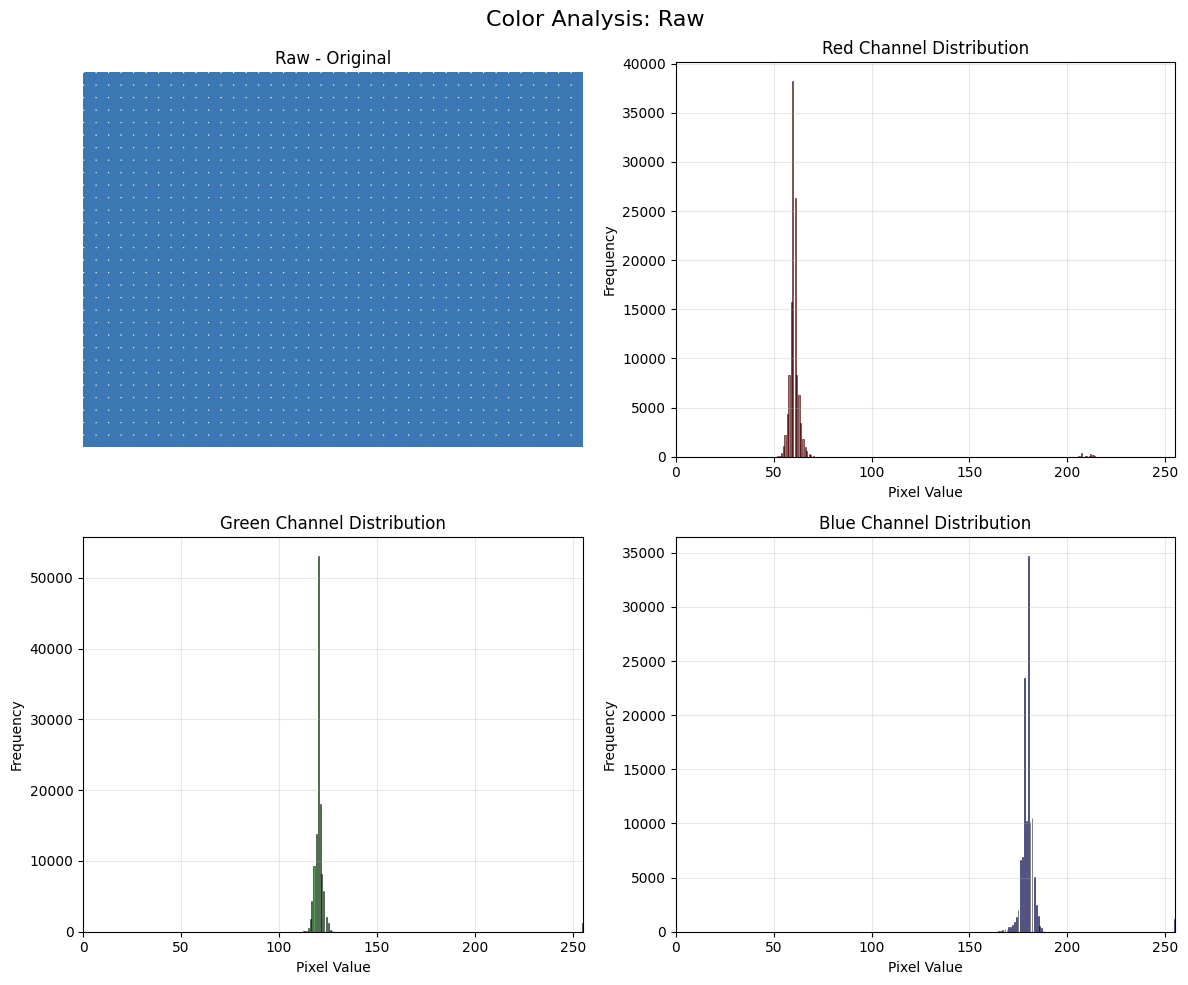


ANALYZING REFERENCE IMAGE
✅ Saved plot to: results/color_analysis_reference.png


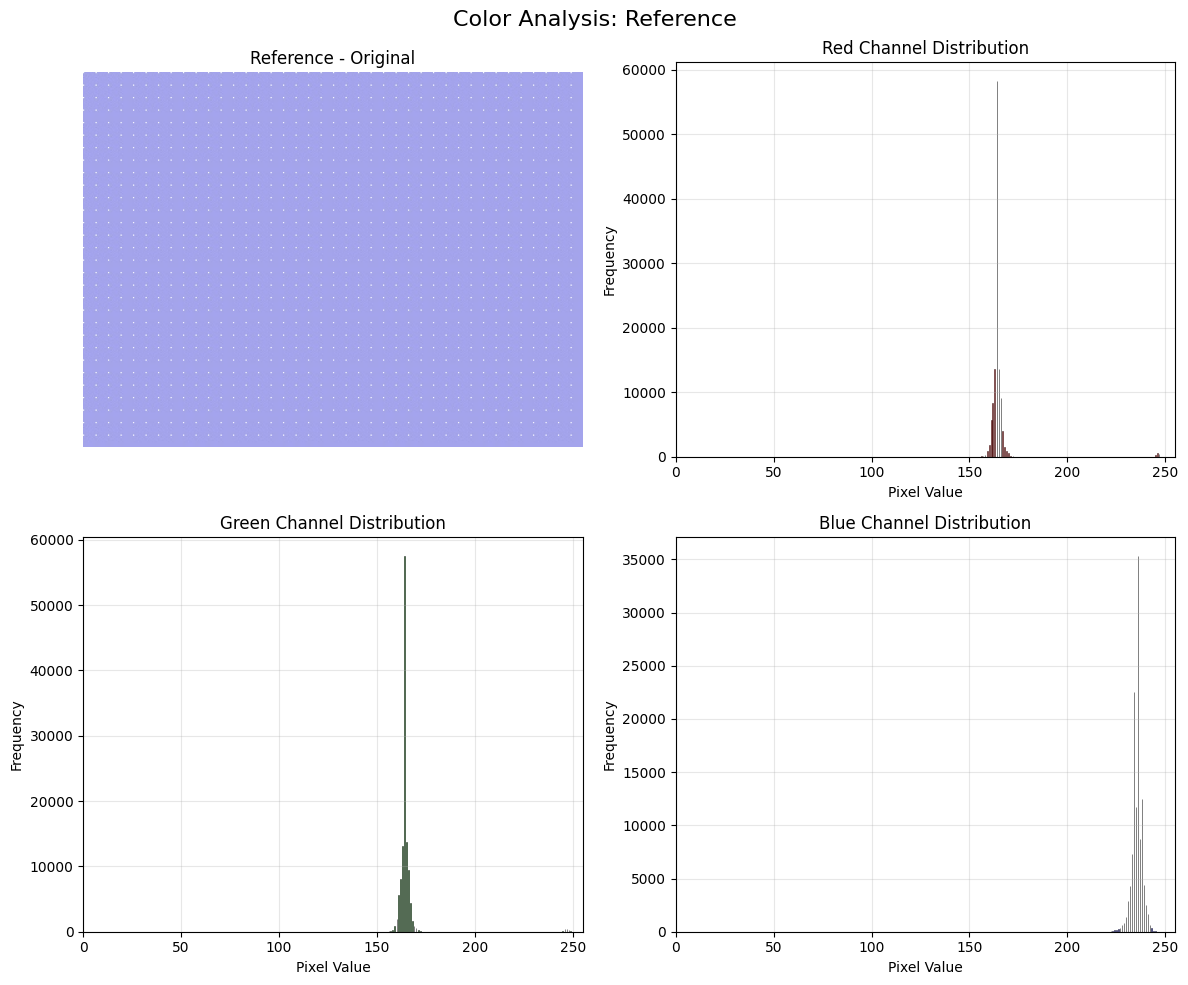


STATISTICS COMPARISON
Metric          Raw        Reference  Change    
--------------------------------------------------
mean_red        61.8       164.8      +166.7%
mean_green      121.4      164.9       +35.7%
mean_blue       180.1      235.6       +30.8%

RATIO ANALYSIS
Metric               Raw          Reference   
--------------------------------------------
Red/Blue Ratio       0.343        0.699       
Blue/Green Ratio     1.483        1.429       

UNDERWATER IMAGE INSIGHTS
🔴 Raw image shows significant red deficiency (typical underwater)
✅ Enhancement improved red channel by 103.8%
✅ Blue dominance reduced in enhanced image

ANALYSIS COMPLETE
Check the 'results' folder for saved plots


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

def analyze_color_distribution(image, title):
    """Analyze color channels of an image"""
    
    # Convert to RGB
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Split channels
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    
    # Create results directory
    os.makedirs("results", exist_ok=True)
    
    # Plot histograms
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title(f"{title} - Original")
    axes[0, 0].axis('off')
    
    # Red channel
    axes[0, 1].hist(r.ravel(), bins=256, color='red', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[0, 1].set_title('Red Channel Distribution')
    axes[0, 1].set_xlim([0, 255])
    axes[0, 1].set_xlabel('Pixel Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Green channel
    axes[1, 0].hist(g.ravel(), bins=256, color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[1, 0].set_title('Green Channel Distribution')
    axes[1, 0].set_xlim([0, 255])
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Blue channel
    axes[1, 1].hist(b.ravel(), bins=256, color='blue', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[1, 1].set_title('Blue Channel Distribution')
    axes[1, 1].set_xlim([0, 255])
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Color Analysis: {title}", fontsize=16)
    plt.tight_layout()
    
    # Save figure
    safe_title = title.lower().replace(" ", "_")
    save_path = f"results/color_analysis_{safe_title}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Saved plot to: {save_path}")
    plt.show()
    
    # Calculate statistics
    stats = {
        'mean_red': float(np.mean(r)),
        'mean_green': float(np.mean(g)),
        'mean_blue': float(np.mean(b)),
        'std_red': float(np.std(r)),
        'std_green': float(np.std(g)),
        'std_blue': float(np.std(b)),
        'red_blue_ratio': float(np.mean(r) / (np.mean(b) + 1e-6)),
        'blue_green_ratio': float(np.mean(b) / (np.mean(g) + 1e-6))
    }
    
    return stats

# Load the test images (using your actual filenames)
print("="*50)
print("LOADING TEST IMAGES")
print("="*50)

raw_img = cv2.imread("data/sample/raw/test_underwater.jpg")
ref_img = cv2.imread("data/sample/reference/test_enhanced.jpg")

# Check if images loaded successfully
if raw_img is None:
    print("❌ Failed to load raw image: data/sample/raw/test_underwater.jpg")
else:
    print(f"✅ Raw image loaded: {raw_img.shape}")

if ref_img is None:
    print("❌ Failed to load reference image: data/sample/reference/test_enhanced.jpg")
else:
    print(f"✅ Reference image loaded: {ref_img.shape}")

# Analyze images if both loaded
if raw_img is not None and ref_img is not None:
    print("\n" + "="*50)
    print("ANALYZING RAW IMAGE")
    print("="*50)
    raw_stats = analyze_color_distribution(raw_img, "Raw")
    
    print("\n" + "="*50)
    print("ANALYZING REFERENCE IMAGE")
    print("="*50)
    ref_stats = analyze_color_distribution(ref_img, "Reference")
    
    # Compare statistics
    if raw_stats and ref_stats:
        print("\n" + "="*50)
        print("STATISTICS COMPARISON")
        print("="*50)
        print(f"{'Metric':<15} {'Raw':<10} {'Reference':<10} {'Change':<10}")
        print("-"*50)
        
        for key in ['mean_red', 'mean_green', 'mean_blue']:
            change = ((ref_stats[key] - raw_stats[key]) / raw_stats[key]) * 100
            print(f"{key:<15} {raw_stats[key]:<10.1f} {ref_stats[key]:<10.1f} {change:>+6.1f}%")
        
        print("\n" + "="*50)
        print("RATIO ANALYSIS")
        print("="*50)
        print(f"{'Metric':<20} {'Raw':<12} {'Reference':<12}")
        print("-"*44)
        print(f"{'Red/Blue Ratio':<20} {raw_stats['red_blue_ratio']:<12.3f} {ref_stats['red_blue_ratio']:<12.3f}")
        print(f"{'Blue/Green Ratio':<20} {raw_stats['blue_green_ratio']:<12.3f} {ref_stats['blue_green_ratio']:<12.3f}")
        
        # Underwater image insights
        print("\n" + "="*50)
        print("UNDERWATER IMAGE INSIGHTS")
        print("="*50)
        
        if raw_stats['red_blue_ratio'] < 0.5:
            print("🔴 Raw image shows significant red deficiency (typical underwater)")
        else:
            print("✅ Raw image has decent red preservation")
            
        if ref_stats['red_blue_ratio'] > raw_stats['red_blue_ratio']:
            improvement = ((ref_stats['red_blue_ratio'] - raw_stats['red_blue_ratio']) / raw_stats['red_blue_ratio']) * 100
            print(f"✅ Enhancement improved red channel by {improvement:.1f}%")
        
        if ref_stats['blue_green_ratio'] < raw_stats['blue_green_ratio']:
            print("✅ Blue dominance reduced in enhanced image")
else:
    print("\n❌ Cannot proceed with analysis - images not loaded properly")
    
print("\n" + "="*50)
print("ANALYSIS COMPLETE")
print("="*50)
print("Check the 'results' folder for saved plots")